# Diurnal cycle of temperature and precipitation (100 km data)

Maps every grid column's longitude to a **local solar time** offset from UTC
(`local_hour = (utc_hour + lon/15) mod 24`), bins all samples by local hour,
and averages within each bin to get the mean "daily trajectory" of a field --
independent of which UTC time or which longitude a sample actually came from.

Four regions:
1. **Global land** (excluding high latitudes, see below)
2. **Global ocean** (same latitude limit)
3. **NE Pacific stratus deck** (marine boundary-layer cloud region off the US
   west coast: 15-30N, 110-135W)
4. **SE US** (summertime land-convection region: 28-35N, 80-90W)

Data: `gs://vcm-ml-scratch/andrep/2025-07-25-X-SHiELD-AMIP-FME-3h.zarr/`
(100 km / 1deg, 3-hourly). Period: JJA 2016 (one season, chosen so both the
stratus deck and SE US convective regimes are in their most active season) --
short enough to load fully into memory in ~30s; extend to more
years/seasons by concatenating additional time slices if you want smoother
precip statistics.

### Why anomalies, not raw values

Because the local-hour bins for a *specific* time-of-day are populated by a
specific, geographically clustered set of longitudes (an artifact of only
having discrete 3-hourly UTC sampling -- see the markdown note in the next
section), naively averaging raw temperature/precip by local-hour bin mixes
in each bin's *particular mix of continents and climate zones*, not just the
time-of-day physics. The fix: subtract each grid column's own time-mean
first, then bin the **anomalies** by local hour. That isolates the diurnal
cycle shape from the very different mean climates being averaged together.


## Setup

In [1]:
import cftime
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import xarray as xr

plt.rcParams["figure.dpi"] = 100


In [2]:
ZARR = "gs://vcm-ml-scratch/andrep/2025-07-25-X-SHiELD-AMIP-FME-3h.zarr/"

ds = xr.open_zarr(ZARR)
t0 = cftime.DatetimeJulian(2016, 6, 1)
t1 = cftime.DatetimeJulian(2016, 9, 1)
sub = ds.sel(time=slice(t0, t1))

temp = sub["air_temperature_at_two_meters"].load().values - 273.15  # K -> degC
precip = sub["PRATEsfc"].load().values * 86400.0  # kg/m2/s -> mm/day
land_fraction = ds["land_fraction"].load().values  # static (lat, lon), 0-1

lat = ds["latitude"].values
lon = ds["longitude"].values  # 0..360 deg East
times = sub["time"].values

print(f"{len(times)} timesteps, {temp.shape} grid, {times[0]} to {times[-1]}")


737 timesteps, (737, 180, 360) grid, 2016-06-01 00:00:00 to 2016-09-01 00:00:00


### Local solar time and the anomaly correction

`local_hour` depends only on `(utc_hour, lon)`, so it is the same 2D array
for every field. For a *fixed* local-hour bin, only the (utc_hour, lon)
combinations that land in that bin contribute -- and since utc_hour only
takes 8 discrete values (3-hourly) each contributes just a ~1-hour-wide band
of longitude 15deg wide (matching the 1h bin width used below with 24 bins,
or a full 3h-wide contiguous band for the 8-bin case used further down). Over
a full day those bands tile all 360deg of longitude, so a **wide** region
(e.g. the whole globe) is fully sampled either way -- but a **narrow**
region (like the two subregions below) only has enough longitude span to
populate a handful of local-hour bins directly out of 24. That's why the
regional composites use 8 times (3-hourly, the data's native cadence) while
the global composites can safely use finer bins -- for consistency, and to
avoid this bin-count subtlety entirely, every composite below uses the same
**8 bins**, matching the 3-hourly native resolution.


In [3]:
NBINS = 8
BIN_EDGES = np.linspace(0.0, 24.0, NBINS + 1)
BIN_CENTERS = 0.5 * (BIN_EDGES[:-1] + BIN_EDGES[1:])

utc_hour = np.array([t.hour + t.minute / 60.0 for t in times])
local_hour = (utc_hour[:, None] + (lon / 15.0)[None, :]) % 24.0  # (ntime, nlon)

# Per-gridpoint time-mean removed before compositing (see markdown above).
temp_anom = temp - temp.mean(axis=0, keepdims=True)
precip_anom = precip - precip.mean(axis=0, keepdims=True)


In [4]:
def region_mask(lat_bounds, lon_bounds, land=None):
    """Boolean (nlat, nlon) mask for a lat/lon box, optionally land-only or ocean-only."""
    lat_ok = (lat >= lat_bounds[0]) & (lat <= lat_bounds[1])
    lon_ok = (lon >= lon_bounds[0]) & (lon <= lon_bounds[1])
    mask = lat_ok[:, None] & lon_ok[None, :]
    if land is True:
        mask = mask & (land_fraction > 0.5)
    elif land is False:
        mask = mask & (land_fraction <= 0.5)
    return mask


def diurnal_composite(field_anom, mask):
    """Area-weighted mean anomaly per local-hour bin for points under ``mask``.

    ``field_anom`` is (ntime, nlat, nlon); returns (bin_centers, mean_anomaly).
    """
    ilat, ilon = np.where(mask)
    weights = np.cos(np.radians(lat[ilat]))  # cos(lat) area weight, per point
    bin_idx = np.clip(np.digitize(local_hour[:, ilon], BIN_EDGES) - 1, 0, NBINS - 1)
    vals = field_anom[:, ilat, ilon]
    w2d = np.broadcast_to(weights, vals.shape)
    sums = np.array([(vals[bin_idx == b] * w2d[bin_idx == b]).sum() for b in range(NBINS)])
    wsums = np.array([w2d[bin_idx == b].sum() for b in range(NBINS)])
    return BIN_CENTERS, sums / wsums


def peak_trough(hours, values):
    """(hour_of_max, hour_of_min, peak-to-trough amplitude) for a diurnal curve."""
    return hours[np.argmax(values)], hours[np.argmin(values)], values.max() - values.min()


## Regions

- **Global land / ocean**: `|lat| <= 60` to stay clear of continuous polar
  daylight in NH summer, which has no diurnal cycle to speak of and would
  just add noise.
- **NE Pacific stratus deck**: 15-30N, 110-135W (ocean only) -- classic
  subtropical marine stratocumulus region, subsiding air over cool water.
- **SE US**: 28-35N, 80-90W (land only) -- summertime land-convection region
  (Florida/Georgia/Alabama), dominated by afternoon thunderstorms.


In [5]:
REGIONS = {
    "land (global, |lat|<=60)": region_mask((-60, 60), (0, 360), land=True),
    "ocean (global, |lat|<=60)": region_mask((-60, 60), (0, 360), land=False),
    "NE Pacific stratus (15-30N, 110-135W)": region_mask((15, 30), (225, 250), land=False),
    "SE US (28-35N, 80-90W)": region_mask((28, 35), (270, 280), land=True),
}
for name, mask in REGIONS.items():
    print(f"{name:38s} n_gridpoints={mask.sum()}")


land (global, |lat|<=60)               n_gridpoints=11430
ocean (global, |lat|<=60)              n_gridpoints=31770
NE Pacific stratus (15-30N, 110-135W)  n_gridpoints=362
SE US (28-35N, 80-90W)                 n_gridpoints=52


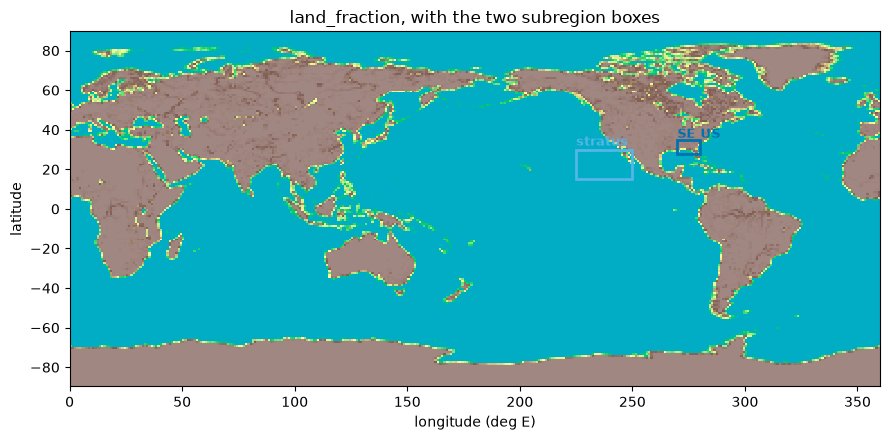

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.pcolormesh(lon, lat, land_fraction, cmap="terrain", vmin=-0.3, vmax=1.3)

box_style = dict(fill=False, lw=2)
ax.add_patch(mpatches.Rectangle((225, 15), 25, 15, edgecolor="C0", **box_style))
ax.text(225, 32, "stratus", color="C0", fontsize=9, weight="bold")
ax.add_patch(mpatches.Rectangle((270, 28), 10, 7, edgecolor="C3", **box_style))
ax.text(270, 36, "SE US", color="C3", fontsize=9, weight="bold")

ax.set_xlabel("longitude (deg E)")
ax.set_ylabel("latitude")
ax.set_title("land_fraction, with the two subregion boxes")
fig.tight_layout()


## Global land vs. ocean

The classic result: land has a large-amplitude diurnal temperature range
(strong daytime heating, nighttime radiative cooling) and an afternoon
convective precipitation peak; ocean's thermal inertia damps the temperature
cycle to almost nothing, and its precipitation (dominated by tropical marine
convection) peaks in the early morning instead of the afternoon.


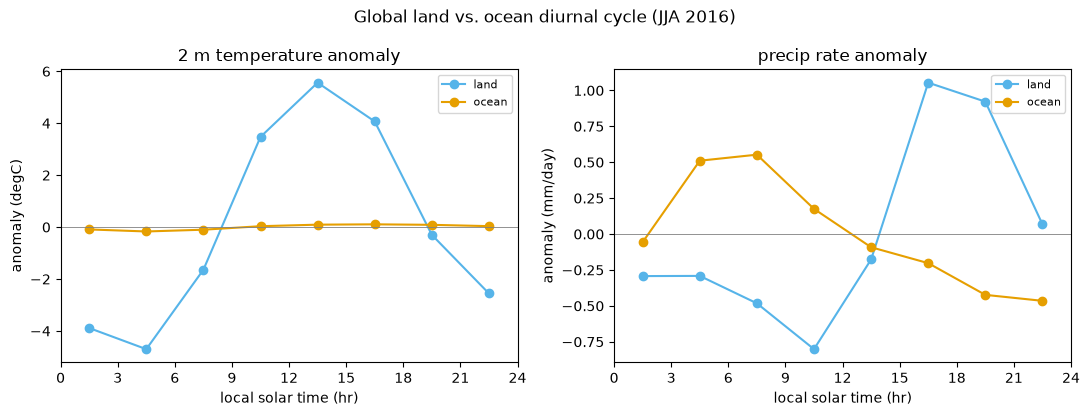

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for name in ["land (global, |lat|<=60)", "ocean (global, |lat|<=60)"]:
    hours, t_vals = diurnal_composite(temp_anom, REGIONS[name])
    _, p_vals = diurnal_composite(precip_anom, REGIONS[name])
    label = name.split(" (")[0]
    axes[0].plot(hours, t_vals, marker="o", label=label)
    axes[1].plot(hours, p_vals, marker="o", label=label)

axes[0].set_title("2 m temperature anomaly")
axes[0].set_ylabel("anomaly (degC)")
axes[1].set_title("precip rate anomaly")
axes[1].set_ylabel("anomaly (mm/day)")
for ax in axes:
    ax.set_xlabel("local solar time (hr)")
    ax.set_xticks(range(0, 25, 3))
    ax.axhline(0, color="gray", lw=0.6)
    ax.legend(fontsize=8)
fig.suptitle("Global land vs. ocean diurnal cycle (JJA 2016)")
fig.tight_layout()


## Stratus deck vs. SE US convection

The two subregions are chosen to be physically opposite: the stratus deck's
precipitation (drizzle) peaks before dawn, when overnight longwave cooling at
cloud top deepens the boundary layer and the cloud is thickest; it is
suppressed in the afternoon once solar heating warms and thins the deck (the
textbook "stratus burns off" pattern). SE US precipitation is the opposite --
suppressed overnight, peaking in mid-to-late afternoon as surface heating
triggers convection, lagging a few hours behind the temperature peak.


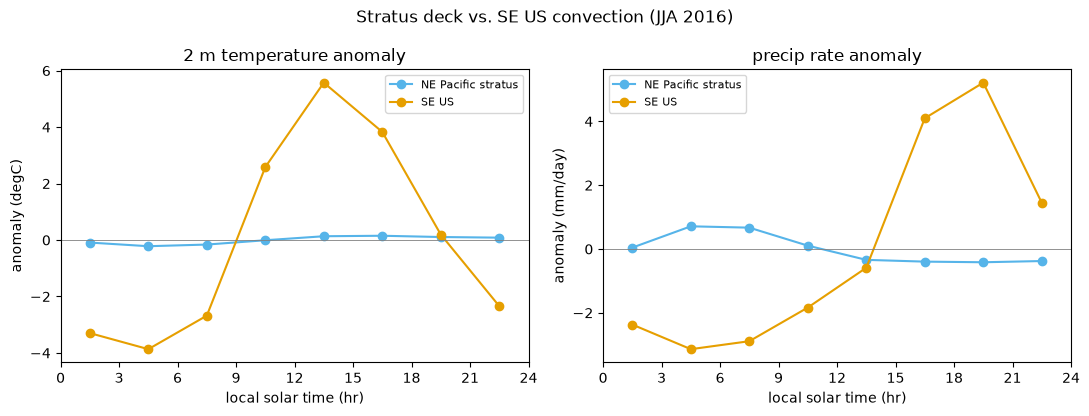

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for name in ["NE Pacific stratus (15-30N, 110-135W)", "SE US (28-35N, 80-90W)"]:
    hours, t_vals = diurnal_composite(temp_anom, REGIONS[name])
    _, p_vals = diurnal_composite(precip_anom, REGIONS[name])
    label = name.split(" (")[0]
    axes[0].plot(hours, t_vals, marker="o", label=label)
    axes[1].plot(hours, p_vals, marker="o", label=label)

axes[0].set_title("2 m temperature anomaly")
axes[0].set_ylabel("anomaly (degC)")
axes[1].set_title("precip rate anomaly")
axes[1].set_ylabel("anomaly (mm/day)")
for ax in axes:
    ax.set_xlabel("local solar time (hr)")
    ax.set_xticks(range(0, 25, 3))
    ax.axhline(0, color="gray", lw=0.6)
    ax.legend(fontsize=8)
fig.suptitle("Stratus deck vs. SE US convection (JJA 2016)")
fig.tight_layout()


## All four regions together

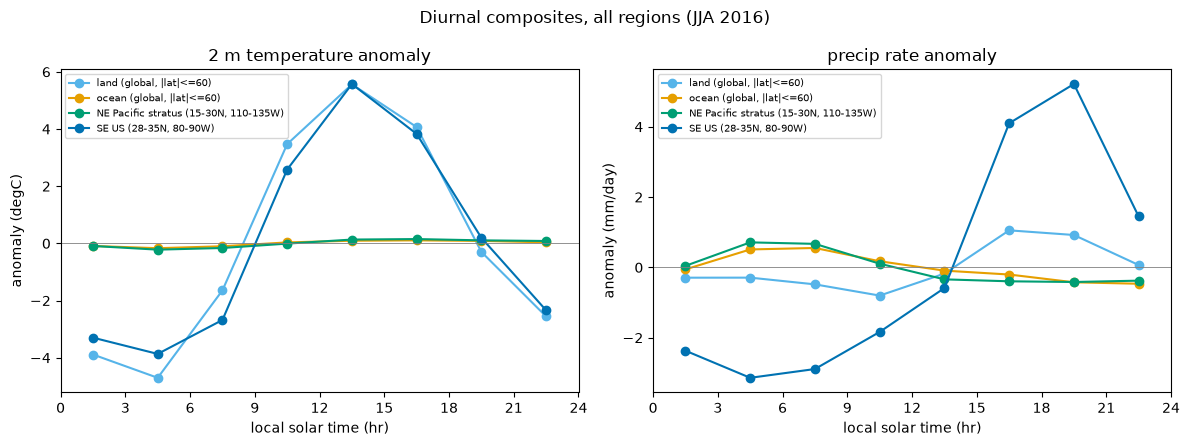

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, mask in REGIONS.items():
    hours, t_vals = diurnal_composite(temp_anom, mask)
    _, p_vals = diurnal_composite(precip_anom, mask)
    axes[0].plot(hours, t_vals, marker="o", label=name)
    axes[1].plot(hours, p_vals, marker="o", label=name)

axes[0].set_title("2 m temperature anomaly")
axes[0].set_ylabel("anomaly (degC)")
axes[1].set_title("precip rate anomaly")
axes[1].set_ylabel("anomaly (mm/day)")
for ax in axes:
    ax.set_xlabel("local solar time (hr)")
    ax.set_xticks(range(0, 25, 3))
    ax.axhline(0, color="gray", lw=0.6)
    ax.legend(fontsize=7)
fig.suptitle("Diurnal composites, all regions (JJA 2016)")
fig.tight_layout()


In [10]:
rows = []
for name, mask in REGIONS.items():
    hours, t_vals = diurnal_composite(temp_anom, mask)
    _, p_vals = diurnal_composite(precip_anom, mask)
    t_peak, t_trough, t_amp = peak_trough(hours, t_vals)
    p_peak, p_trough, p_amp = peak_trough(hours, p_vals)
    rows.append({
        "region": name,
        "T_peak_LST": t_peak, "T_trough_LST": t_trough, "T_amplitude_degC": round(t_amp, 2),
        "P_peak_LST": p_peak, "P_trough_LST": p_trough, "P_amplitude_mm/day": round(p_amp, 2),
    })
pd.DataFrame(rows).set_index("region")


,T_peak_LST,T_trough_LST,T_amplitude_degC,P_peak_LST,P_trough_LST,P_amplitude_mm/day
region,,,,,,
"land (global, |lat|<=60)",13.5,4.5,10.26,16.5,10.5,1.86
"ocean (global, |lat|<=60)",16.5,4.5,0.27,7.5,22.5,1.02
"NE Pacific stratus (15-30N, 110-135W)",16.5,4.5,0.37,4.5,19.5,1.13
"SE US (28-35N, 80-90W)",13.5,4.5,9.44,19.5,4.5,8.36
